# Boston Housing 가격 예측 — 회귀 ML 파이프라인

**데이터**: 506개 보스턴 지역 주택 정보 → 주택 중앙값 가격(medv) 예측  
**유형**: 회귀(Regression) — BMI·타이타닉과 달리 연속값 예측  
**목표**: 피처 엔지니어링 + 여러 회귀 모델 비교 + 최적 모델 저장

| 평가지표 | 의미 |
|----------|------|
| RMSE | 예측 오차의 평균 크기 (단위: $1000) — 낮을수록 좋음 |
| MAE  | 절대 오차 평균 — 이상치에 덜 민감 |
| R²   | 모델이 분산을 설명하는 비율 (1.0=완벽, 0=평균만큼) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

font_path = r'C:\Windows\Fonts\malgun.ttf'
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 로드 완료')

라이브러리 로드 완료


## 1. 데이터 로드 및 기본 탐색

In [2]:
df = pd.read_csv('boston_housing.csv')
print(f'Shape: {df.shape}')
df.head(10)

Shape: (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,0,0.524,6.172,96.1,5.9505,5,311,15.2,396.90,19.15,27.1
8,0.21124,12.5,7.87,0,0.524,5.631,100.0,6.0821,5,311,15.2,386.63,29.93,16.5
9,0.17004,12.5,7.87,0,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9


In [3]:
# 컬럼 설명
col_desc = {
    'crim':    '범죄율',
    'zn':      '25000 sq.ft 초과 주거지 비율',
    'indus':   '비소매 상업지 비율',
    'chas':    '찰스강 인접 여부 (1=인접)',
    'nox':     '일산화질소 농도',
    'rm':      '평균 방 개수',
    'age':     '1940년 이전 건축 비율',
    'dis':     '5개 고용센터까지 가중 거리',
    'rad':     '고속도로 접근성 지수',
    'tax':     '재산세율 (per $10,000)',
    'ptratio': '학생-교사 비율',
    'b':       '흑인 인구 비율 관련 지수',
    'lstat':   '하위 계층 인구 비율 (%)',
    'medv':    '주택 중앙값 가격 ($1000) ← 타겟'
}
desc_df = pd.DataFrame({'컬럼': col_desc.keys(), '설명': col_desc.values()})
print(desc_df.to_string(index=False))

     컬럼                     설명
   crim                    범죄율
     zn  25000 sq.ft 초과 주거지 비율
  indus             비소매 상업지 비율
   chas       찰스강 인접 여부 (1=인접)
    nox               일산화질소 농도
     rm                평균 방 개수
    age         1940년 이전 건축 비율
    dis        5개 고용센터까지 가중 거리
    rad            고속도로 접근성 지수
    tax     재산세율 (per $10,000)
ptratio               학생-교사 비율
      b         흑인 인구 비율 관련 지수
  lstat        하위 계층 인구 비율 (%)
   medv 주택 중앙값 가격 ($1000) ← 타겟


In [4]:
print('=== 결측치 ===')
print(df.isnull().sum())
print()
df.describe().round(2)

=== 결측치 ===
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64



,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


## 2. 탐색적 데이터 분석 (EDA)

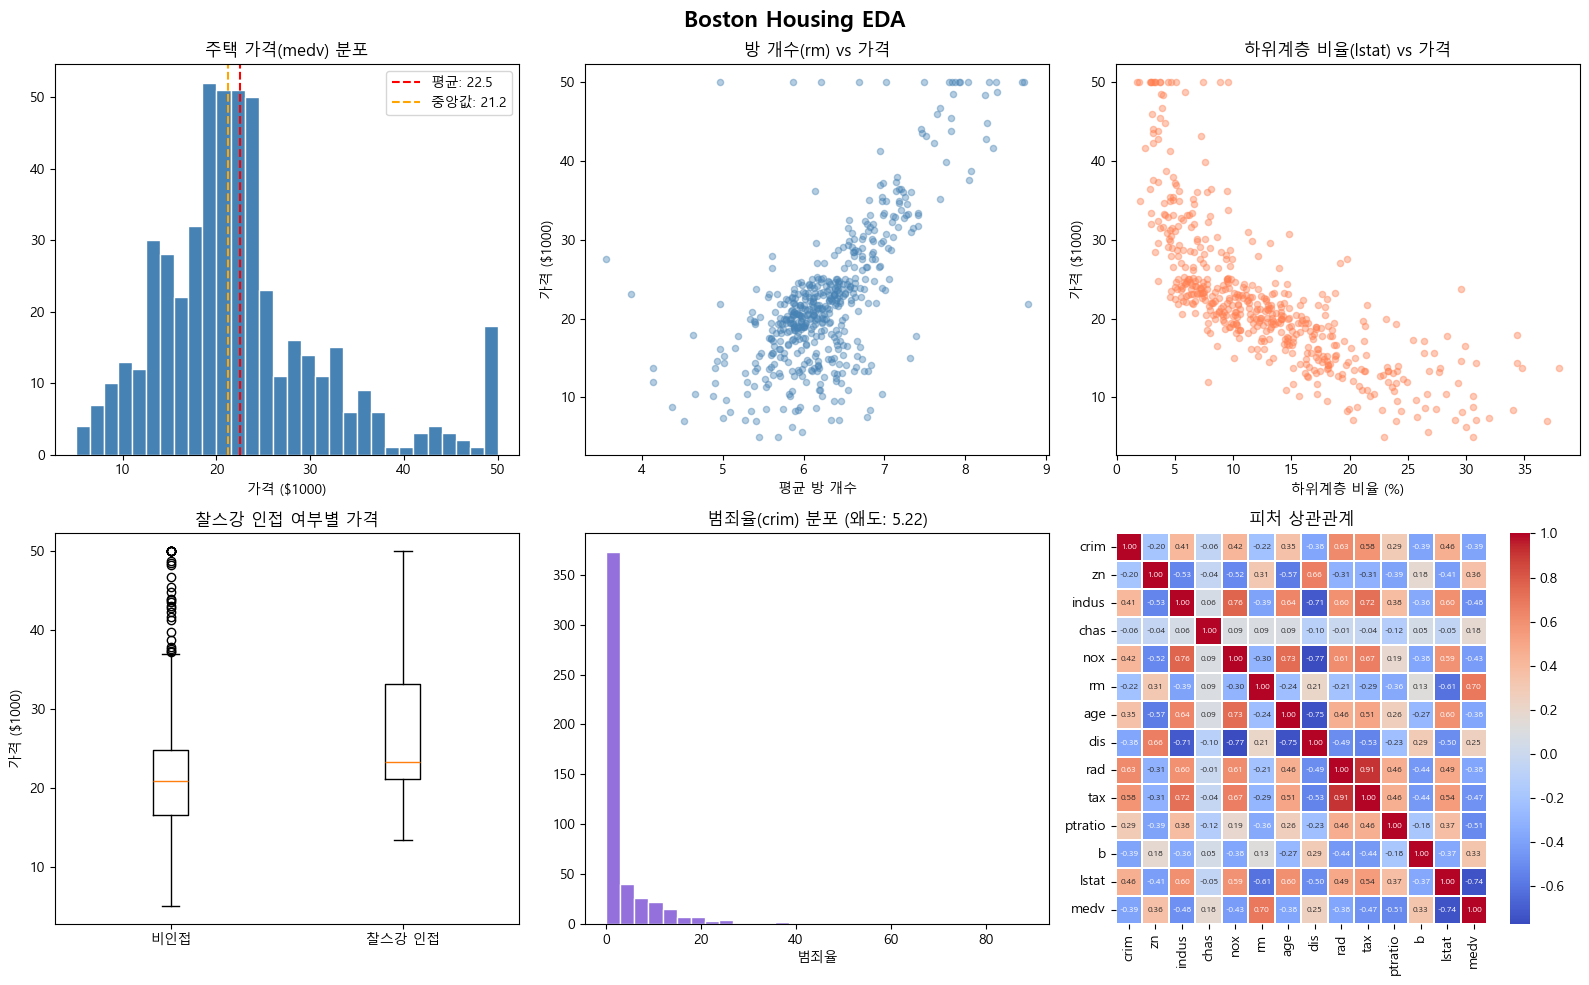

저장: 01_eda.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Boston Housing EDA', fontsize=16, fontweight='bold')

# 타겟(medv) 분포
axes[0, 0].hist(df['medv'], bins=30, color='steelblue', edgecolor='white')
axes[0, 0].axvline(df['medv'].mean(), color='red', linestyle='--', label=f'평균: {df["medv"].mean():.1f}')
axes[0, 0].axvline(df['medv'].median(), color='orange', linestyle='--', label=f'중앙값: {df["medv"].median():.1f}')
axes[0, 0].set_title('주택 가격(medv) 분포')
axes[0, 0].set_xlabel('가격 ($1000)')
axes[0, 0].legend()

# rm(방 개수) vs medv
axes[0, 1].scatter(df['rm'], df['medv'], alpha=0.4, color='steelblue', s=20)
axes[0, 1].set_title('방 개수(rm) vs 가격')
axes[0, 1].set_xlabel('평균 방 개수')
axes[0, 1].set_ylabel('가격 ($1000)')

# lstat(하위계층 비율) vs medv
axes[0, 2].scatter(df['lstat'], df['medv'], alpha=0.4, color='coral', s=20)
axes[0, 2].set_title('하위계층 비율(lstat) vs 가격')
axes[0, 2].set_xlabel('하위계층 비율 (%)')
axes[0, 2].set_ylabel('가격 ($1000)')

# 찰스강 인접 여부별 가격
chas_data = [df[df['chas']==0]['medv'], df[df['chas']==1]['medv']]
axes[1, 0].boxplot(chas_data, labels=['비인접', '찰스강 인접'])
axes[1, 0].set_title('찰스강 인접 여부별 가격')
axes[1, 0].set_ylabel('가격 ($1000)')

# 범죄율(crim) 분포 — 왜도 확인
axes[1, 1].hist(df['crim'], bins=30, color='mediumpurple', edgecolor='white')
axes[1, 1].set_title(f'범죄율(crim) 분포 (왜도: {df["crim"].skew():.2f})')
axes[1, 1].set_xlabel('범죄율')

# 상관관계 히트맵
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 2],
            linewidths=0.3, annot_kws={'size': 6})
axes[1, 2].set_title('피처 상관관계')

plt.tight_layout()
plt.savefig('01_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 01_eda.png')

In [6]:
# medv와의 상관관계 순위
corr_target = df.corr()['medv'].drop('medv').sort_values(key=abs, ascending=False)
print('medv와의 상관관계 (절댓값 기준 내림차순)')
for feat, val in corr_target.items():
    bar = '█' * int(abs(val) * 20)
    print(f'{feat:>8}: {val:+.3f}  {bar}')

medv와의 상관관계 (절댓값 기준 내림차순)
   lstat: -0.738  ██████████████
      rm: +0.695  █████████████
 ptratio: -0.508  ██████████
   indus: -0.484  █████████
     tax: -0.469  █████████
     nox: -0.427  ████████
    crim: -0.388  ███████
     rad: -0.382  ███████
     age: -0.377  ███████
      zn: +0.360  ███████
       b: +0.333  ██████
     dis: +0.250  ████
    chas: +0.175  ███


## 3. 피처 엔지니어링

In [7]:
df_feat = df.copy()

# ── 1) 로그 변환 ──────────────────────────────────────────────
# 왜도가 심한 피처는 로그 변환으로 정규분포에 가깝게 만들어 선형 모델 성능 향상
for col in ['crim', 'zn', 'dis', 'lstat']:
    df_feat[f'log_{col}'] = np.log1p(df_feat[col])  # log(1+x): 0값 안전 처리

# ── 2) 상호작용 피처 ──────────────────────────────────────────
# 방 개수 대비 하위계층 비율 — 주거 품질을 나타내는 복합 지표
df_feat['rm_lstat']  = df_feat['rm'] / (df_feat['lstat'] + 1)

# 세금 × 고속도로 접근성 — 입지 부담을 나타내는 복합 지표
df_feat['tax_rad']   = df_feat['tax'] * df_feat['rad']

# 방 개수 제곱 — 방 개수와 가격의 비선형 관계 포착
df_feat['rm_sq']     = df_feat['rm'] ** 2

new_feats = ['log_crim', 'log_zn', 'log_dis', 'log_lstat', 'rm_lstat', 'tax_rad', 'rm_sq']
print('새로 생성한 피처:')
print(df_feat[new_feats].head())

새로 생성한 피처:
   log_crim    log_zn   log_dis  log_lstat  rm_lstat  tax_rad      rm_sq
0  0.006300  2.944439  1.627278   1.788421  1.099498      296  43.230625
1  0.026944  0.000000  1.786261   2.316488  0.633235      484  41.229241
2  0.026924  0.000000  1.786261   1.615420  1.428429      484  51.624225
3  0.031857  0.000000  1.954757   1.371181  1.776142      666  48.972004
4  0.066770  0.000000  1.954757   1.845300  1.129068      666  51.079609


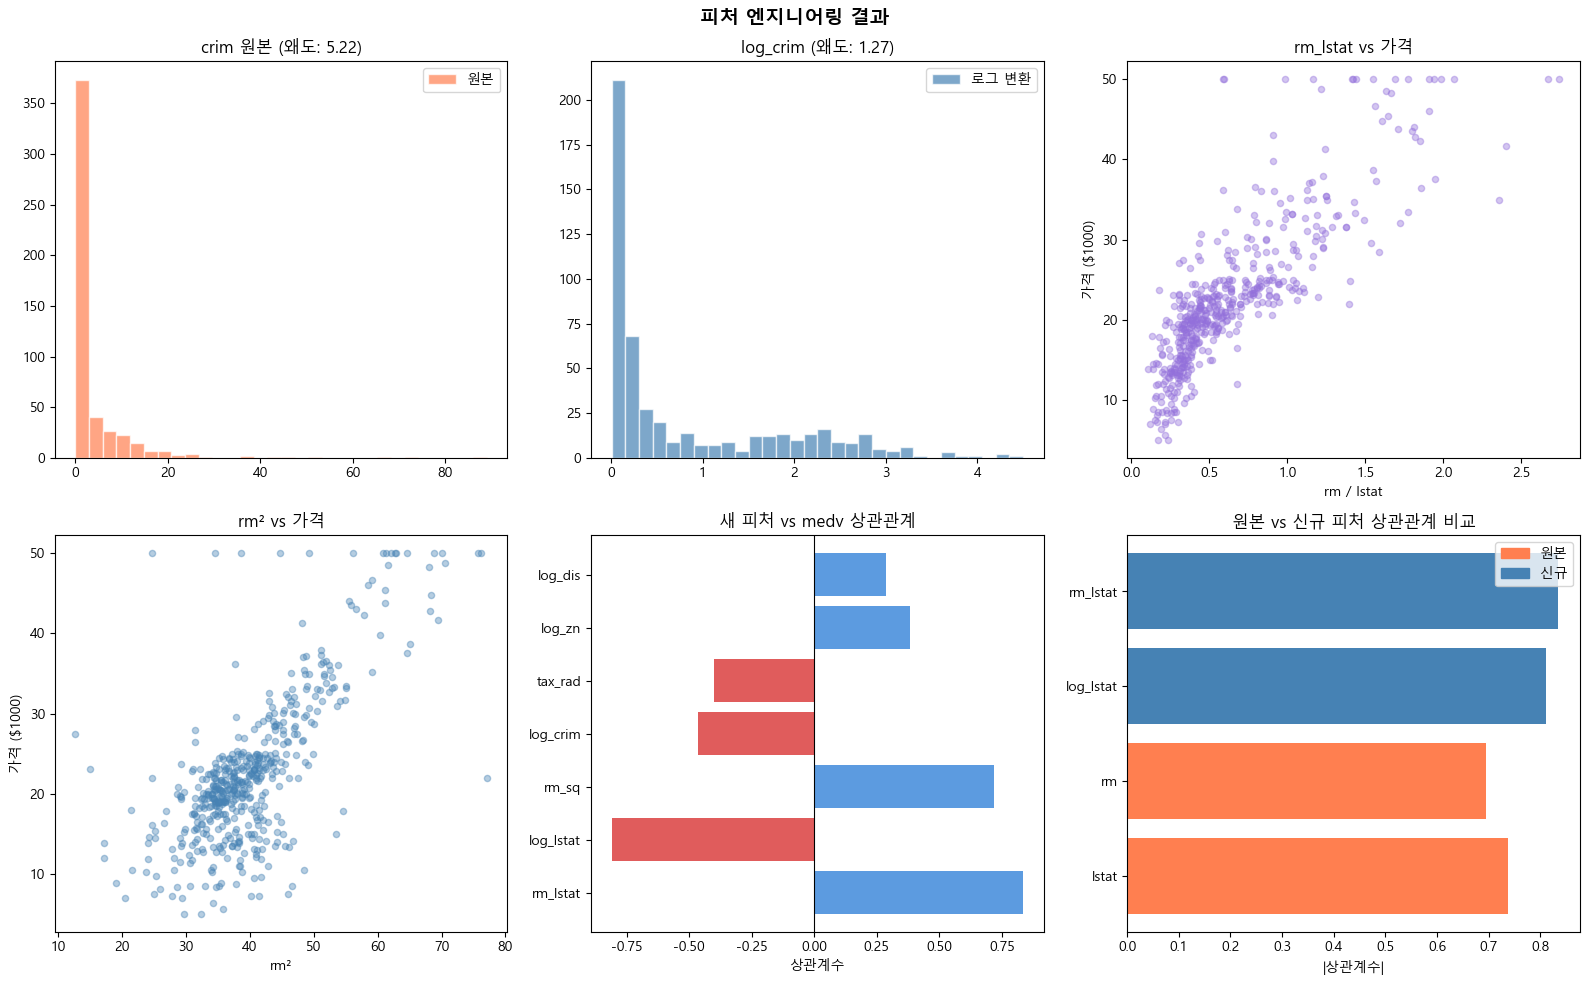

저장: 02_features.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('피처 엔지니어링 결과', fontsize=14, fontweight='bold')

# 로그 변환 전후 비교 (crim)
axes[0, 0].hist(df_feat['crim'], bins=30, color='coral', edgecolor='white', alpha=0.7, label='원본')
axes[0, 0].set_title(f'crim 원본 (왜도: {df_feat["crim"].skew():.2f})')
axes[0, 0].legend()

axes[0, 1].hist(df_feat['log_crim'], bins=30, color='steelblue', edgecolor='white', alpha=0.7, label='로그 변환')
axes[0, 1].set_title(f'log_crim (왜도: {df_feat["log_crim"].skew():.2f})')
axes[0, 1].legend()

# rm_lstat vs medv
axes[0, 2].scatter(df_feat['rm_lstat'], df_feat['medv'], alpha=0.4, color='mediumpurple', s=20)
axes[0, 2].set_title('rm_lstat vs 가격')
axes[0, 2].set_xlabel('rm / lstat')
axes[0, 2].set_ylabel('가격 ($1000)')

# rm_sq vs medv
axes[1, 0].scatter(df_feat['rm_sq'], df_feat['medv'], alpha=0.4, color='steelblue', s=20)
axes[1, 0].set_title('rm² vs 가격')
axes[1, 0].set_xlabel('rm²')
axes[1, 0].set_ylabel('가격 ($1000)')

# 새 피처 상관관계
new_corr = df_feat[new_feats + ['medv']].corr()['medv'].drop('medv').sort_values(key=abs, ascending=False)
colors = ['#5C9BE0' if v > 0 else '#E05C5C' for v in new_corr.values]
axes[1, 1].barh(new_corr.index, new_corr.values, color=colors)
axes[1, 1].set_title('새 피처 vs medv 상관관계')
axes[1, 1].set_xlabel('상관계수')
axes[1, 1].axvline(0, color='black', linewidth=0.8)

# 원본 vs 신규 피처 상관관계 비교
orig_top = [('lstat', df.corr()['medv']['lstat']), ('rm', df.corr()['medv']['rm'])]
new_top  = [('log_lstat', new_corr['log_lstat']), ('rm_lstat', new_corr['rm_lstat'])]
labels = [x[0] for x in orig_top + new_top]
vals   = [x[1] for x in orig_top + new_top]
bar_colors = ['coral']*2 + ['steelblue']*2
axes[1, 2].barh(labels, [abs(v) for v in vals], color=bar_colors)
axes[1, 2].set_title('원본 vs 신규 피처 상관관계 비교')
axes[1, 2].set_xlabel('|상관계수|')
axes[1, 2].legend(handles=[
    plt.Rectangle((0,0),1,1, color='coral', label='원본'),
    plt.Rectangle((0,0),1,1, color='steelblue', label='신규')
])

plt.tight_layout()
plt.savefig('02_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 02_features.png')

## 4. 전처리 및 Train/Test 분할

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 원본 피처 + 새로 생성한 피처 모두 사용
FEATURES = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis',
            'rad', 'tax', 'ptratio', 'b', 'lstat',
            'log_crim', 'log_zn', 'log_dis', 'log_lstat',
            'rm_lstat', 'tax_rad', 'rm_sq']
TARGET = 'medv'

X = df_feat[FEATURES]
y = df_feat[TARGET]

# stratify 없음 — 회귀는 연속값이라 계층 분할 불가
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 회귀 모델(Ridge, Lasso, SVR)은 스케일에 민감하므로 StandardScaler 적용
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'피처 수: {len(FEATURES)}')
print(f'훈련셋: {X_train.shape}, 테스트셋: {X_test.shape}')
print(f'\n타겟 범위: {y.min():.1f} ~ {y.max():.1f} ($1000)')
print(f'타겟 평균: {y.mean():.1f}, 중앙값: {y.median():.1f}')

피처 수: 20
훈련셋: (404, 20), 테스트셋: (102, 20)

타겟 범위: 5.0 ~ 50.0 ($1000)
타겟 평균: 22.5, 중앙값: 21.2


## 5. 모델 학습 및 비교

In [10]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

models = {
    'Linear Regression':   LinearRegression(),
    'Ridge':               Ridge(alpha=1.0),           # L2 규제 — 계수 크기 억제
    'Lasso':               Lasso(alpha=0.1),           # L1 규제 — 불필요 피처 계수를 0으로
    'Random Forest':       RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR':                 SVR(kernel='rbf'),
}

results = []
trained_models = {}

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_sc, y_train)
    elapsed = time.time() - t0

    y_pred = model.predict(X_test_sc)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # 오차의 표준편차 ($1000 단위)
    mae  = mean_absolute_error(y_test, y_pred)           # 평균 절대 오차
    r2   = r2_score(y_test, y_pred)                      # 설명력 (1.0이 최고)

    results.append({'모델': name, 'RMSE': rmse, 'MAE': mae, 'R²': r2,
                    '학습시간(s)': round(elapsed, 3)})
    trained_models[name] = model
    print(f'{name:<22} | RMSE: {rmse:.3f} | MAE: {mae:.3f} | R²: {r2:.4f} | {elapsed:.3f}s')

# R² 기준 내림차순 정렬
results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
print('\n=== 모델 비교 ===')
results_df

Linear Regression      | RMSE: 3.654 | MAE: 2.264 | R²: 0.8179 | 0.092s
Ridge                  | RMSE: 3.766 | MAE: 2.369 | R²: 0.8066 | 0.029s
Lasso                  | RMSE: 4.135 | MAE: 2.554 | R²: 0.7669 | 0.028s
Random Forest          | RMSE: 2.836 | MAE: 2.048 | R²: 0.8903 | 0.495s
Gradient Boosting      | RMSE: 2.766 | MAE: 2.037 | R²: 0.8957 | 0.369s
SVR                    | RMSE: 4.812 | MAE: 2.583 | R²: 0.6842 | 0.009s

=== 모델 비교 ===


,모델,RMSE,MAE,R²,학습시간(s)
0,Gradient Boosting,2.766204,2.036934,0.895657,0.369
1,Random Forest,2.836394,2.048196,0.890294,0.495
2,Linear Regression,3.653960,2.263530,0.817936,0.092
3,Ridge,3.765798,2.368518,0.806621,0.029
4,Lasso,4.134540,2.554422,0.766896,0.028
5,SVR,4.812191,2.583015,0.684222,0.009


```
해석

  Linear Regression이 가장 좋은 이유
  - Boston 데이터(506행)는 작고, 피처 엔지니어링으로 이미 선형 관계를 잘 만들어줬기 때문에 규제가 오히려 성능을 낮춤

  Ridge — alpha가 클수록 성능 하락
  - 규제가 강해질수록 계수를 너무 억제해서 예측력 감소
  - 피처는 하나도 제거 안 함 (0/20개)

  Lasso — alpha가 클수록 피처 제거 증가
  - alpha=0.1 → 7개 제거, R²=0.767
  - alpha=1.0 → 14개 제거, R²=0.725
  - alpha=10  → 전체 20개 제거 → R²=-0.023 (평균값만 예측하는 수준으로 붕괴)

  결론

  ▎ 이 데이터에서는 규제가 필요 없을 만큼 피처 품질이 좋고 데이터가 깔끔합니다.
  ▎ 실전에서는 Linear → Ridge → Lasso 순으로 시도하며 alpha를 조정하는 것이 일반적입니다.
```

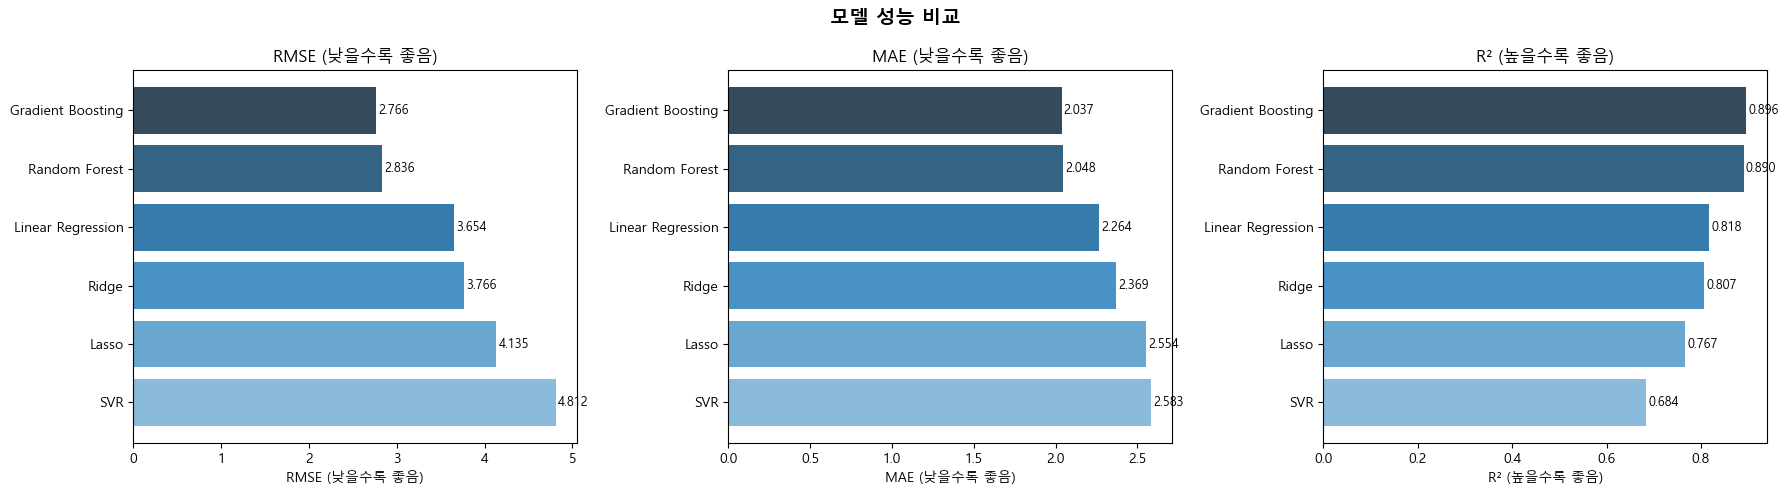

저장: 03_model_comparison.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('모델 성능 비교', fontsize=14, fontweight='bold')

metrics = [('RMSE', 'RMSE (낮을수록 좋음)', True),
           ('MAE',  'MAE (낮을수록 좋음)',  True),
           ('R²',   'R² (높을수록 좋음)',   False)]
colors = sns.color_palette('Blues_d', len(results_df))

for ax, (col, label, ascending) in zip(axes, metrics):
    sorted_df = results_df.sort_values(col, ascending=not ascending)
    bars = ax.barh(sorted_df['모델'], sorted_df[col], color=colors)
    ax.set_xlabel(label)
    ax.set_title(label)
    for bar, val in zip(bars, sorted_df[col]):
        ax.text(val + 0.005 * sorted_df[col].max(),
                bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 03_model_comparison.png')

## 6. 최적 모델 상세 분석

In [12]:
from sklearn.inspection import permutation_importance

best_name  = results_df.iloc[0]['모델']
best_model = trained_models[best_name]
y_pred_best = best_model.predict(X_test_sc)

print(f'최적 모델: {best_name}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.3f} ($1000)')
print(f'MAE:  {mean_absolute_error(y_test, y_pred_best):.3f} ($1000)')
print(f'R²:   {r2_score(y_test, y_pred_best):.4f}')

최적 모델: Gradient Boosting
RMSE: 2.766 ($1000)
MAE:  2.037 ($1000)
R²:   0.8957


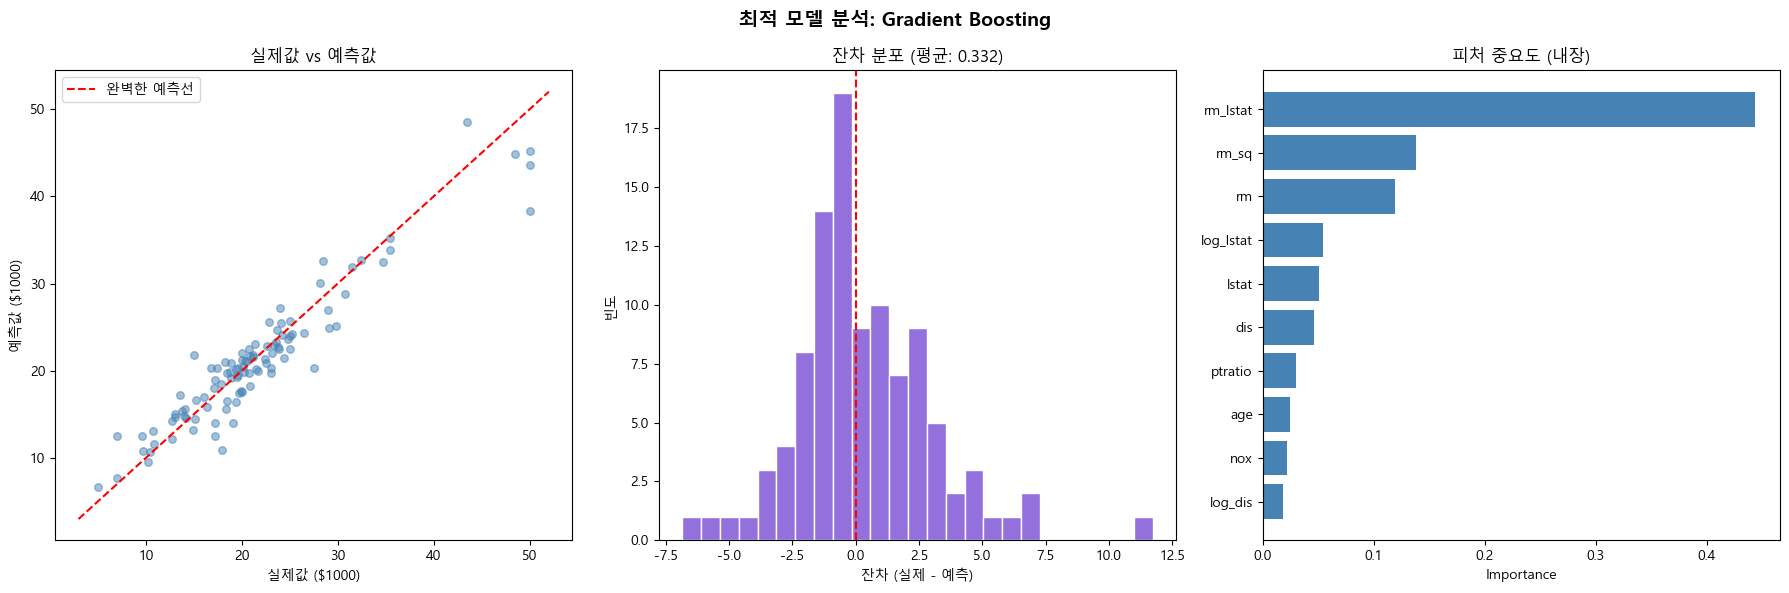

저장: 04_best_model_analysis.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'최적 모델 분석: {best_name}', fontsize=14, fontweight='bold')

# ── 실제값 vs 예측값 산점도 ──────────────────────────────────
# 완벽한 예측이면 모든 점이 대각선(y=x) 위에 위치
axes[0].scatter(y_test, y_pred_best, alpha=0.5, color='steelblue', s=30)
lims = [min(y_test.min(), y_pred_best.min()) - 2,
        max(y_test.max(), y_pred_best.max()) + 2]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='완벽한 예측선')
axes[0].set_xlabel('실제값 ($1000)')
axes[0].set_ylabel('예측값 ($1000)')
axes[0].set_title('실제값 vs 예측값')
axes[0].legend()

# ── 잔차 분포 ────────────────────────────────────────────────
# 잔차(residual) = 실제값 - 예측값
# 잔차가 0 중심으로 정규분포를 이루면 모델이 편향 없이 잘 학습된 것
residuals = y_test - y_pred_best
axes[1].hist(residuals, bins=25, color='mediumpurple', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('잔차 (실제 - 예측)')
axes[1].set_ylabel('빈도')
axes[1].set_title(f'잔차 분포 (평균: {residuals.mean():.3f})')

# ── 피처 중요도 ──────────────────────────────────────────────
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    errors = None
    imp_title = '피처 중요도 (내장)'
else:
    perm = permutation_importance(best_model, X_test_sc, y_test,
                                  n_repeats=10, random_state=42)
    importances = perm.importances_mean
    errors = perm.importances_std
    imp_title = '피처 중요도 (Permutation)'

feat_df = pd.DataFrame({'피처': FEATURES, '중요도': importances})
feat_df = feat_df.sort_values('중요도').tail(10).reset_index(drop=True)
axes[2].barh(feat_df['피처'], feat_df['중요도'], color='steelblue',
             xerr=errors[feat_df.index] if errors is not None else None, capsize=3)
axes[2].set_title(imp_title)
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('04_best_model_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 04_best_model_analysis.png')

## 7. 하이퍼파라미터 튜닝 (Gradient Boosting)

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':  [100, 200, 300],   # 트리 개수
    'max_depth':     [3, 5, 7],         # 트리 깊이 (얕을수록 과적합 억제)
    'learning_rate': [0.05, 0.1, 0.2],  # 학습률 (낮을수록 안정적, 트리 수 더 필요)
}

gb = GradientBoostingRegressor(random_state=42)

# neg_root_mean_squared_error: sklearn은 최대화 방향이므로 RMSE에 음수를 붙임
grid_search = GridSearchCV(gb, param_grid, cv=5,
                           scoring='neg_root_mean_squared_error',
                           n_jobs=-1, verbose=0)
grid_search.fit(X_train_sc, y_train)

print(f'최적 파라미터: {grid_search.best_params_}')
print(f'CV RMSE: {-grid_search.best_score_:.3f}')

best_gb = grid_search.best_estimator_
y_pred_gb = best_gb.predict(X_test_sc)
print(f'\n테스트 RMSE (튜닝 후): {np.sqrt(mean_squared_error(y_test, y_pred_gb)):.3f}')
print(f'테스트 R²   (튜닝 후): {r2_score(y_test, y_pred_gb):.4f}')

최적 파라미터: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}
CV RMSE: 3.401

테스트 RMSE (튜닝 후): 2.597
테스트 R²   (튜닝 후): 0.9080


## 8. 최종 모델 저장

In [15]:
import pickle

final_bundle = {
    'model':    best_gb,
    'scaler':   scaler,
    'features': FEATURES,
}

with open('boston_model.pkl', 'wb') as f:
    pickle.dump(final_bundle, f)

print('모델 저장 완료: boston_model.pkl')

# 로드 테스트 — 샘플 한 행으로 예측
with open('boston_model.pkl', 'rb') as f:
    loaded = pickle.load(f)

sample_row = X_test.iloc[[0]].copy()
sample_sc  = loaded['scaler'].transform(sample_row)
pred_val   = loaded['model'].predict(sample_sc)[0]
actual_val = y_test.iloc[0]

print(f'\n샘플 예측')
print(f'실제 가격: ${actual_val:.1f}k')
print(f'예측 가격: ${pred_val:.1f}k')
print(f'오차:      ${abs(pred_val - actual_val):.1f}k')

모델 저장 완료: boston_model.pkl

샘플 예측
실제 가격: $23.6k
예측 가격: $23.6k
오차:      $0.0k


## 9. 결과 요약

In [16]:
print('='*58)
print('     Boston Housing 가격 예측 ML 파이프라인 결과 요약')
print('='*58)
print(f'  데이터셋:  506행 × {len(FEATURES)}개 피처')
print(f'  타겟:      주택 중앙값 가격 (회귀)')
print(f'  훈련/테스트: 404 / 102')
print()
print('  모델별 R²:')
for _, row in results_df.iterrows():
    marker = ' ★' if row['모델'] == best_name else ''
    print(f"  {row['모델']:<22}: R²={row['R²']:.4f}  RMSE={row['RMSE']:.3f}{marker}")
print()
print(f'  GridSearch GB  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_gb)):.3f} ($1000)')
print(f'  GridSearch GB  R²:   {r2_score(y_test, y_pred_gb):.4f}')
print(f'  저장 파일: boston_model.pkl')
print('='*58)

     Boston Housing 가격 예측 ML 파이프라인 결과 요약
  데이터셋:  506행 × 20개 피처
  타겟:      주택 중앙값 가격 (회귀)
  훈련/테스트: 404 / 102

  모델별 R²:
  Gradient Boosting     : R²=0.8957  RMSE=2.766 ★
  Random Forest         : R²=0.8903  RMSE=2.836
  Linear Regression     : R²=0.8179  RMSE=3.654
  Ridge                 : R²=0.8066  RMSE=3.766
  Lasso                 : R²=0.7669  RMSE=4.135
  SVR                   : R²=0.6842  RMSE=4.812

  GridSearch GB  RMSE: 2.597 ($1000)
  GridSearch GB  R²:   0.9080
  저장 파일: boston_model.pkl
